# Análisis Exploratorio de Datos (EDA) — Parte I
## Estadísticas descriptivas y tendencias temporales

**Proyecto:** Bullying escolar y apuestas online en adolescentes argentinos  
**Autor:** Federico Oscar Giglio  
**Fecha:** Marzo 2026  
**Fuente:** Ministerio de Educación Argentina — Datos abiertos

## 1. Imports, rutas y carga de datos limpios

Se cargan los 8 datasets ya normalizados desde `data/clean/`.
A partir de esta etapa no se trabaja sobre los archivos originales de `data/raw/`.
Las rutas se construyen con `os.path.join` desde la raíz absoluta del proyecto
para garantizar compatibilidad entre máquinas.

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

BASE  = r"C:\Users\fedeo\Desktop\PROYECTO UNICEF"
CLEAN = os.path.join(BASE, "data", "clean")

df_mat_2022 = pd.read_csv(os.path.join(CLEAN, "matricula_total_2022.csv"))
df_mat_2023 = pd.read_csv(os.path.join(CLEAN, "matricula_total_2023.csv"))
df_mat_2024 = pd.read_csv(os.path.join(CLEAN, "matricula_total_2024.csv"))

df_edad_2022 = pd.read_csv(os.path.join(CLEAN, "matricula_edad_2022.csv"))
df_edad_2023 = pd.read_csv(os.path.join(CLEAN, "matricula_edad_2023.csv"))
df_edad_2024 = pd.read_csv(os.path.join(CLEAN, "matricula_edad_2024.csv"))

abandono_reciente  = pd.read_csv(os.path.join(CLEAN, "abandono_reciente.csv"))
abandono_historico = pd.read_csv(os.path.join(CLEAN, "abandono_historico.csv"))

abandono_reciente["division"]  = abandono_reciente["division"].str.strip()
abandono_historico["division"] = abandono_historico["division"].str.strip()

print("✓ 8 datasets cargados desde data/clean/")

✓ 8 datasets cargados desde data/clean/


## 2. Estadísticas descriptivas — Tasas de abandono

Se calculan las métricas de resumen (media, desvío estándar, mínimo, máximo y percentiles)
para los dos datasets de abandono escolar.
El objetivo es tener una primera lectura cuantitativa del rango de valores,
detectar posibles outliers y entender la dispersión entre provincias.

In [20]:
print("=== ABANDONO RECIENTE (2012-2024) ===")
print(abandono_reciente.describe().round(2))

print("\n=== ABANDONO HISTÓRICO (2003-2016) ===")
print(abandono_historico.describe().round(2))

=== ABANDONO RECIENTE (2012-2024) ===
       prim_total  prim_1  prim_2  prim_3  prim_4  prim_5  prim_6  prim_7  \
count       27.00   27.00   27.00   27.00   27.00   27.00   27.00   13.00   
mean         0.54    0.14    0.63    0.94    0.60    0.87    0.16    0.17   
std          0.51    0.76    1.13    0.78    0.76    0.74    0.99    0.87   
min         -0.61   -1.40   -1.64   -0.60   -0.84   -0.56   -1.63   -1.25   
25%          0.15   -0.29   -0.07    0.41    0.06    0.36   -0.26   -0.43   
50%          0.52    0.17    0.60    0.89    0.62    0.78    0.07    0.24   
75%          0.88    0.66    1.22    1.41    1.03    1.24    0.48    0.90   
max          1.54    1.49    3.38    2.89    2.99    2.45    2.93    1.64   

       sec_total  sec_7  sec_8  sec_9  sec_10  sec_11  sec_12  
count      27.00  15.00  27.00  27.00   27.00   27.00   27.00  
mean        8.45   2.62   4.77   6.34    9.23    7.74   19.44  
std         2.24   2.07   2.90   2.84    2.79    2.71    7.66  
min         

## 3. Exploración de estructura — Abandono reciente

Antes de construir visualizaciones temporales, se inspecciona la estructura del dataset.
Los datos de abandono están organizados en formato *wide*: cada columna representa
un año escolar o grado. Para graficar tendencias en el tiempo será necesario
transformarlos a formato *long*, donde cada fila es una observación única
(provincia + año + tasa). Esta celda identifica los nombres exactos de columnas
como paso previo a esa transformación.

In [21]:
print(abandono_reciente.columns.tolist())
print()
print(abandono_reciente.head())

['division', 'estructura', 'prim_total', 'prim_1', 'prim_2', 'prim_3', 'prim_4', 'prim_5', 'prim_6', 'prim_7', 'sec_total', 'sec_7', 'sec_8', 'sec_9', 'sec_10', 'sec_11', 'sec_12']

         division estructura  prim_total    prim_1    prim_2    prim_3  \
0      Total País        NaN    0.516238 -0.147195  0.919616  0.882836   
1    Buenos Aires        6-6    0.405685 -0.691481  1.179272  0.894652   
2       Conurbano        6-6    0.589701 -0.547618  1.425830  1.210142   
3  Resto de Bs As        6-6    0.109314 -0.918872  0.783844  0.384918   
4       Catamarca        6-6   -0.134867 -0.851125 -0.906516  0.421163   

     prim_4    prim_5    prim_6    prim_7  sec_total     sec_7     sec_8  \
0  0.629229  0.778037  0.071039  0.236353   8.047195  2.171372  4.197437   
1  0.508399  0.661824 -0.232935       NaN   6.688718  1.058992  2.846020   
2  0.691566  0.832068 -0.202899       NaN   6.833344  0.661915  2.860349   
3  0.212823  0.385332 -0.281698       NaN   6.457570  1.682237  2.823

## 4. Visualización I — Tasa de abandono por grado (nivel nacional)

Se comparan las tasas de abandono promedio para cada grado de primaria y secundaria
a nivel nacional, usando la fila "Total País" del dataset.
El objetivo es identificar en qué momento de la trayectoria escolar se concentra
el abandono y si existe una diferencia estructural entre los dos niveles.

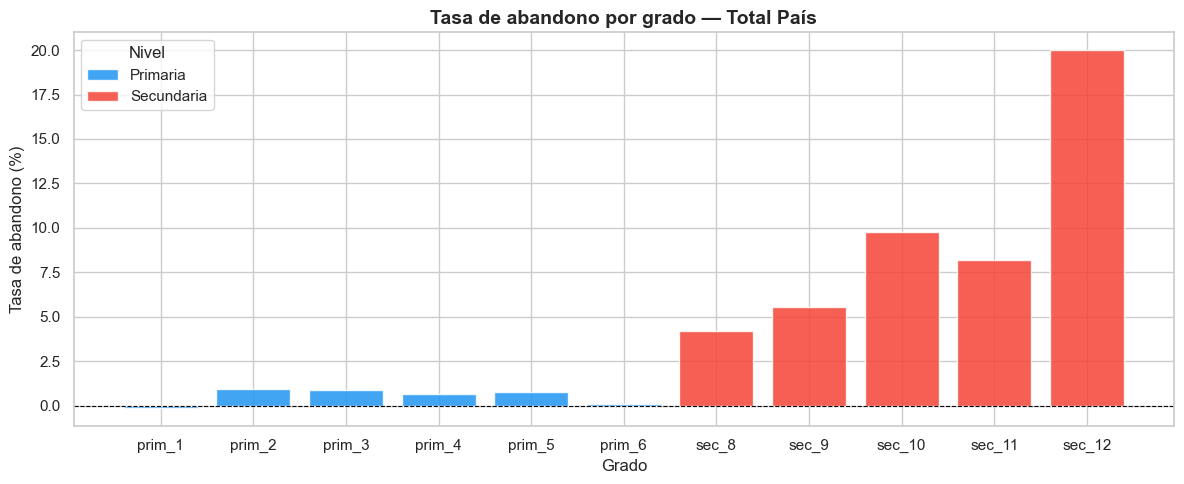

✓ Gráfico guardado en outputs/


In [22]:
# Extraer fila Total País
total = abandono_reciente[abandono_reciente["division"] == "Total País"].iloc[0]

# Columnas de grados (excluimos totales y columnas no numéricas)
grados_prim = ["prim_1","prim_2","prim_3","prim_4","prim_5","prim_6"]
grados_sec  = ["sec_8","sec_9","sec_10","sec_11","sec_12"]

# Armar un dataframe para graficar
import pandas as pd

datos_grafico = pd.DataFrame({
    "grado": grados_prim + grados_sec,
    "tasa":  [total[g] for g in grados_prim + grados_sec],
    "nivel": ["Primaria"] * len(grados_prim) + ["Secundaria"] * len(grados_sec)
})

# Graficar
fig, ax = plt.subplots(figsize=(12, 5))

colores = {"Primaria": "#2196F3", "Secundaria": "#F44336"}

for nivel, grupo in datos_grafico.groupby("nivel"):
    ax.bar(grupo["grado"], grupo["tasa"], color=colores[nivel], label=nivel, alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Tasa de abandono por grado — Total País", fontsize=14, fontweight="bold")
ax.set_xlabel("Grado")
ax.set_ylabel("Tasa de abandono (%)")
ax.legend(title="Nivel")
plt.tight_layout()
plt.savefig("../outputs/01_abandono_por_grado.png", dpi=150)
plt.show()

print("✓ Gráfico guardado en outputs/")

## 5. Inspección previa — División y abandono secundario por provincia

Antes de graficar, se inspeccionan los valores únicos de la columna `division`
para identificar filas de totales nacionales, subtotales regionales y provincias reales.
Separar correctamente estos grupos es necesario para que el gráfico
muestre solo jurisdicciones comparables entre sí.

In [23]:
print(abandono_reciente[["division", "sec_total"]].to_string())

                  division  sec_total
0               Total País   8.047195
1             Buenos Aires   6.688718
2                Conurbano   6.833344
3           Resto de Bs As   6.457570
4                Catamarca   6.236703
5                    Chaco  14.277318
6                   Chubut   6.574256
7   Ciudad de Buenos Aires   7.217677
8                  Cordoba   7.578904
9               Corrientes   8.714399
10              Entre Rios   8.833676
11                 Formosa  11.008788
12                   Jujuy   8.898953
13                La Pampa   7.248376
14                La Rioja   6.592841
15                 Mendoza  10.184185
16                Misiones  11.978467
17                 Neuquén   6.830259
18               Rio Negro   7.682055
19                   Salta  12.058387
20                San Juan   8.478413
21                San Luis   5.102963
22              Santa Cruz  10.863033
23                Santa Fe  11.271101
24     Santiago Del Estero   9.100119
25        Ti

## 6. Visualización II — Tasa de abandono secundario por provincia

Se compara la tasa total de abandono secundario (`sec_total`) entre las 24 provincias,
ordenada de mayor a menor. Las barras en rojo superan el promedio nacional,
las azules están por debajo. Se excluyen los subtotales regionales
(Conurbano y Resto de Bs As) para que todas las unidades sean comparables.

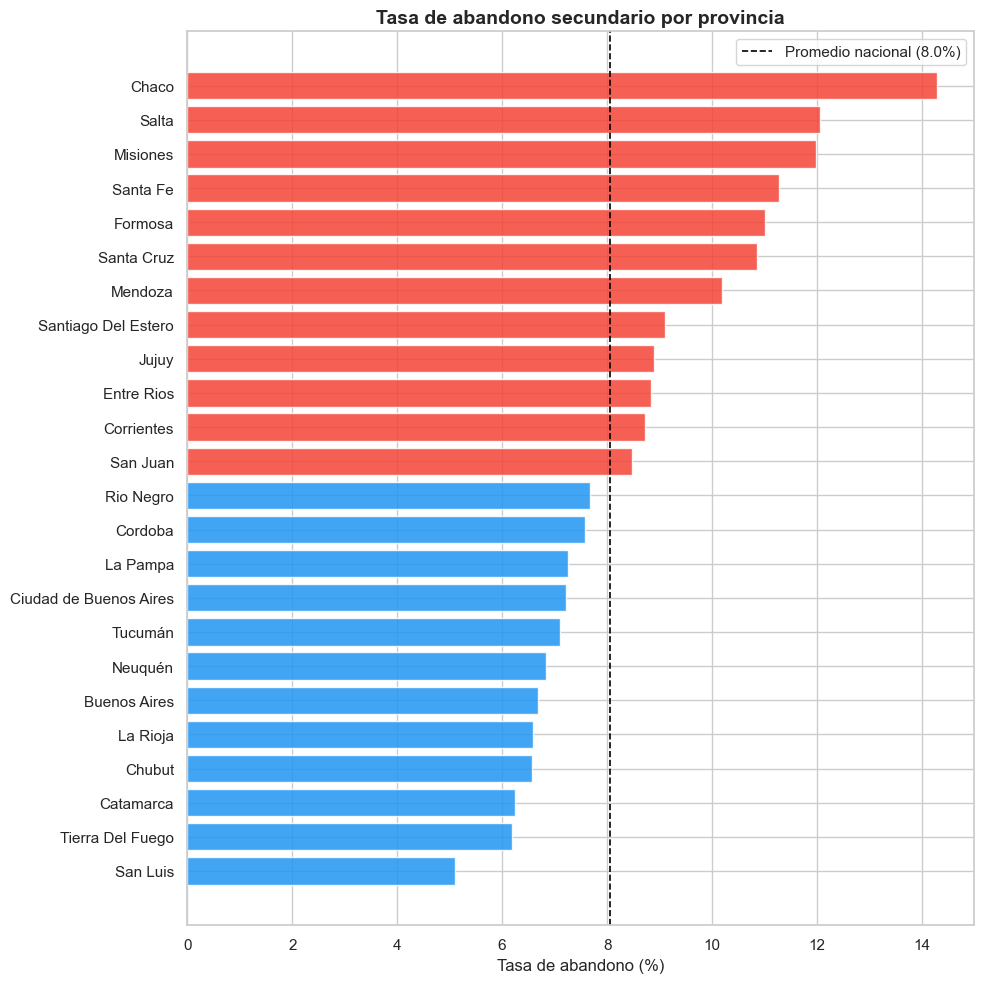

✓ Gráfico guardado en outputs/


In [24]:
excluir = ["Total País", "Conurbano", "Resto de Bs As"]
provincias = abandono_reciente[~abandono_reciente["division"].isin(excluir)].copy()
provincias = provincias.sort_values("sec_total", ascending=True)

promedio = abandono_reciente[
    abandono_reciente["division"] == "Total País"
]["sec_total"].values[0]

fig, ax = plt.subplots(figsize=(10, 10))

colores = ["#F44336" if v > promedio else "#2196F3" for v in provincias["sec_total"]]

ax.barh(provincias["division"], provincias["sec_total"], color=colores, alpha=0.85)
ax.axvline(promedio, color="black", linewidth=1.2, linestyle="--",
           label=f"Promedio nacional ({promedio:.1f}%)")

ax.set_title("Tasa de abandono secundario por provincia", fontsize=14, fontweight="bold")
ax.set_xlabel("Tasa de abandono (%)")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/02_abandono_por_provincia.png", dpi=150)
plt.show()

print("✓ Gráfico guardado en outputs/")